In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import os
from pathlib import Path

# Set the style for plots
sns.set_palette("deep")

In [3]:
WD_PATH = Path(f"{os.getcwd()}")
print(WD_PATH)
CONTROL_PATH = Path('/home/awelch/GIPL/control_model_10yrs/out')
print(CONTROL_PATH)

/home/awelch/GIPL/warming_experiment_2C
/home/awelch/GIPL/control_model_10yrs/out


In [4]:
# Load control and experimental data
control_data = np.loadtxt(CONTROL_PATH/'mean.txt', skiprows=0, unpack=False)
experimental_data = np.loadtxt(WD_PATH/'out/mean.txt', skiprows=0,  unpack=False)

# Convert to pd data frame
control_df = pd.DataFrame(control_data, columns=['id', 'time', 'Tair', 'snow', '0.01m', '0.08m', '0.13m', '0.24m', '0.38m', '0.53m', '0.67m', 'idk', 'idk', 'idk'])
experimental_df = pd.DataFrame(experimental_data, columns = ['id', 'time', 'Tair', 'snow', '0.01m', '0.08m', '0.13m', '0.24m', '0.38m', '0.53m', '0.67m', 'idk', 'idk', 'idk'])

# Select needed columns
# Select 2nd column (index 1) and columns 5-11 (indices 4-10)
control_df = control_df.iloc[:, [1] + list(range(4, 11))]
experimental_df = experimental_df.iloc[:, [1] + list(range(4, 11))]

In [5]:
# Create a new 'year' column assigning years 1 to 10
control_df['year'] = range(1, 11)
experimental_df['year'] = range(1, 11)

# Set 'year' as the index
control_df.set_index('year', inplace=True)
experimental_df.set_index('year', inplace=True)

# Assuming the data has columns: 'time', '0.01m', '0.08m', '0.13m', '0.24m', '0.38m', '0.53m', '0.67m'
depths = ['0.01m', '0.08m', '0.13m', '0.24m', '0.38m', '0.53m', '0.67m']

print(control_df.head())
print(experimental_df.head())

        time  0.01m  0.08m  0.13m  0.24m  0.38m  0.53m  0.67m
year                                                         
1      183.0 -2.545 -3.741 -4.296 -4.500 -4.631 -4.726 -4.793
2      548.0 -2.325 -3.461 -3.988 -4.173 -4.264 -4.341 -4.384
3      913.0 -2.227 -3.340 -3.855 -4.033 -4.115 -4.188 -4.224
4     1278.0 -2.183 -3.288 -3.798 -3.973 -4.048 -4.117 -4.148
5     1643.0 -2.131 -3.226 -3.731 -3.903 -3.976 -4.044 -4.076
        time  0.01m  0.08m  0.13m  0.24m  0.38m  0.53m  0.67m
year                                                         
1      183.0 -2.505 -3.718 -4.292 -4.505 -4.640 -4.740 -4.810
2      548.0 -2.110 -3.270 -3.827 -4.026 -4.132 -4.223 -4.272
3      913.0 -1.786 -2.942 -3.499 -3.699 -3.803 -3.900 -3.954
4     1278.0 -1.434 -2.601 -3.170 -3.374 -3.477 -3.581 -3.642
5     1643.0 -1.178 -2.343 -2.920 -3.125 -3.225 -3.330 -3.396


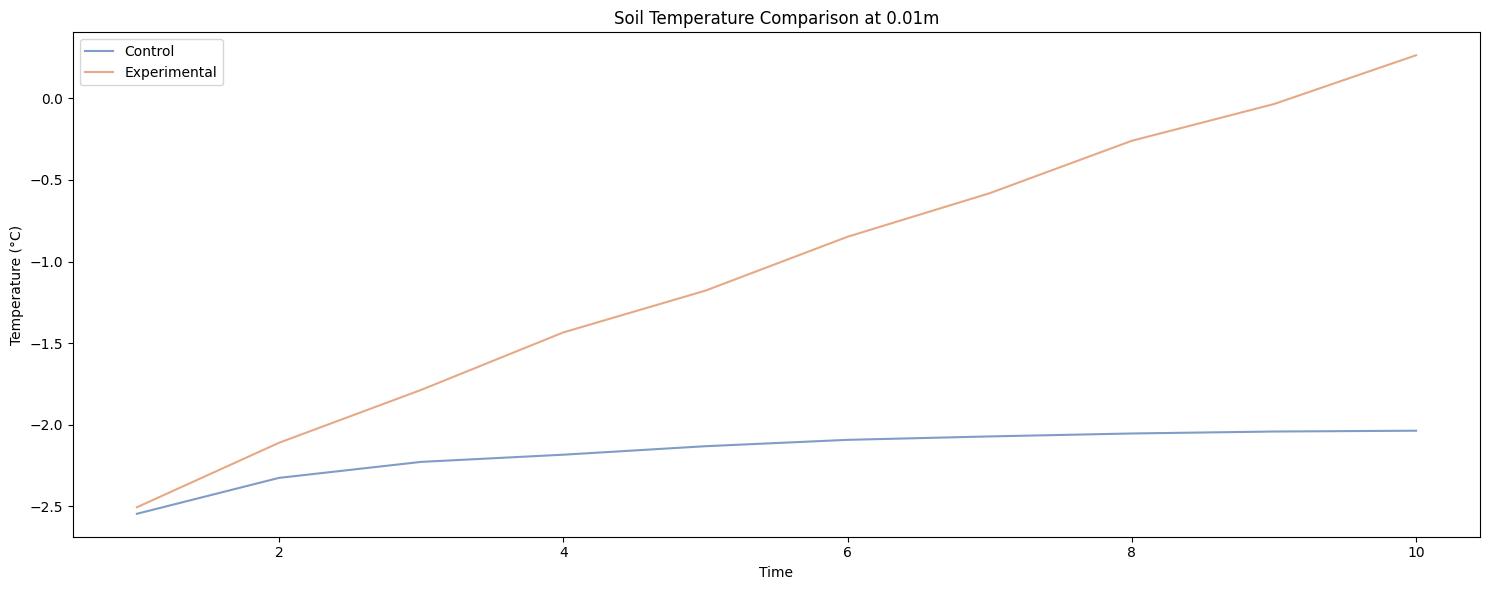

Statistics for 0.01m:
Control mean temperature: -2.17°C
Experimental mean temperature: -1.05°C
Temperature difference: 1.12°C
T-statistic: -3.8097
P-value: 0.0013




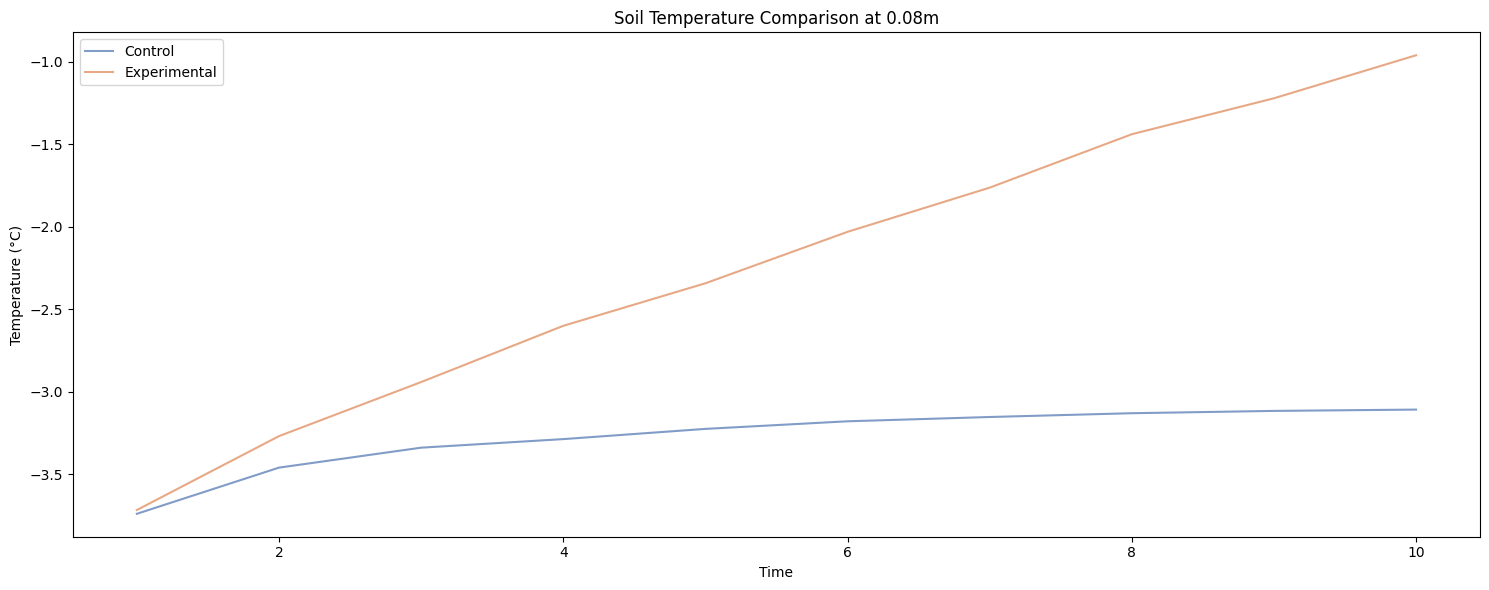

Statistics for 0.08m:
Control mean temperature: -3.27°C
Experimental mean temperature: -2.23°C
Temperature difference: 1.05°C
T-statistic: -3.5475
P-value: 0.0023




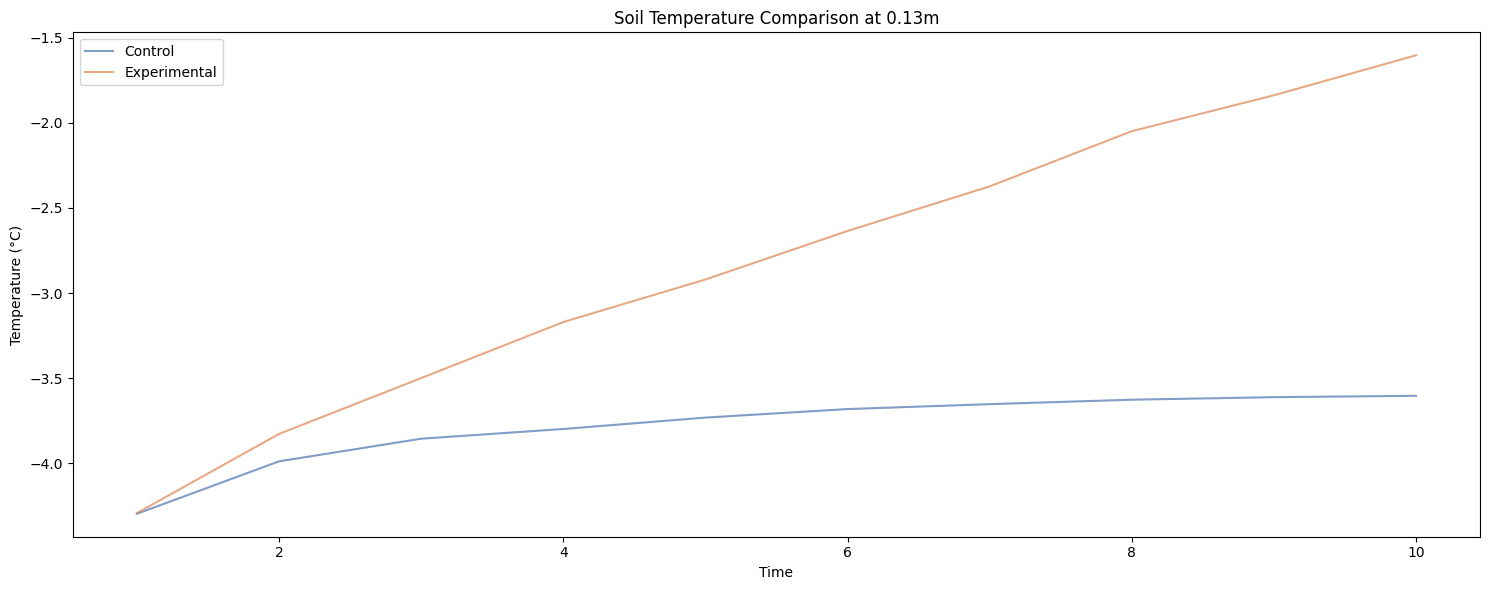

Statistics for 0.13m:
Control mean temperature: -3.78°C
Experimental mean temperature: -2.82°C
Temperature difference: 0.96°C
T-statistic: -3.3431
P-value: 0.0036




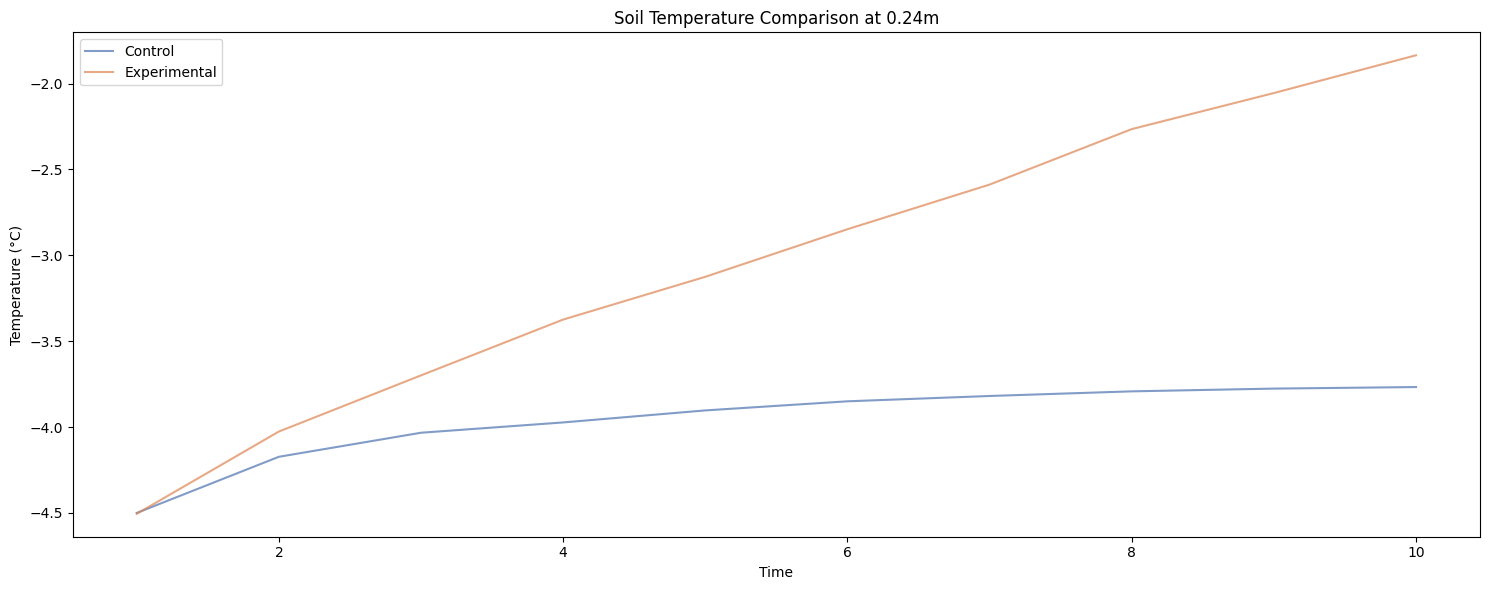

Statistics for 0.24m:
Control mean temperature: -3.96°C
Experimental mean temperature: -3.03°C
Temperature difference: 0.93°C
T-statistic: -3.2289
P-value: 0.0047




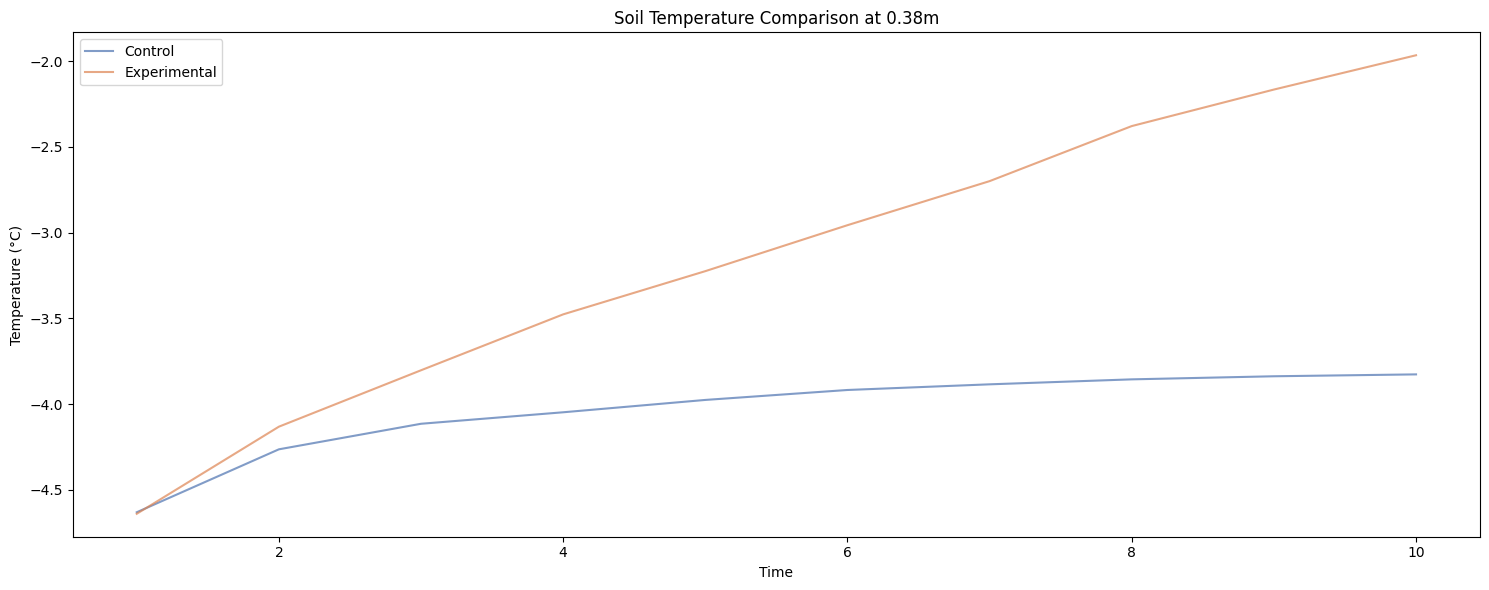

Statistics for 0.38m:
Control mean temperature: -4.04°C
Experimental mean temperature: -3.14°C
Temperature difference: 0.89°C
T-statistic: -3.0885
P-value: 0.0063




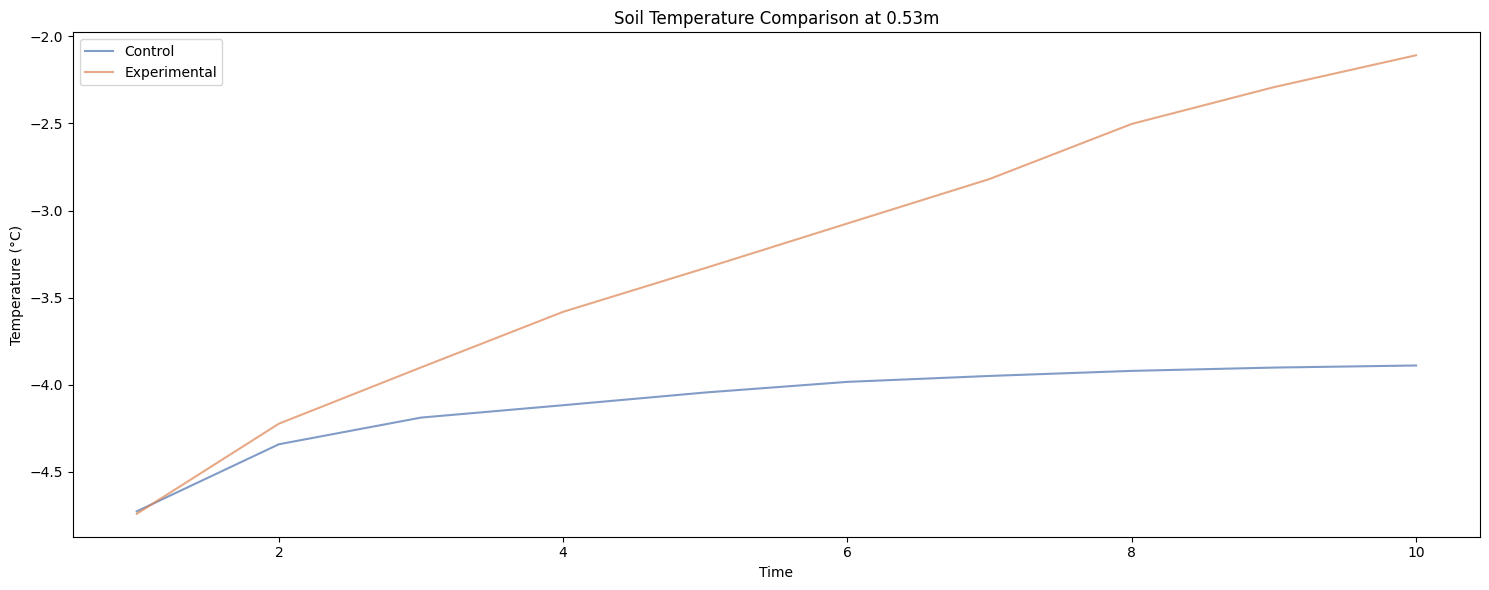

Statistics for 0.53m:
Control mean temperature: -4.11°C
Experimental mean temperature: -3.26°C
Temperature difference: 0.85°C
T-statistic: -2.9773
P-value: 0.0081




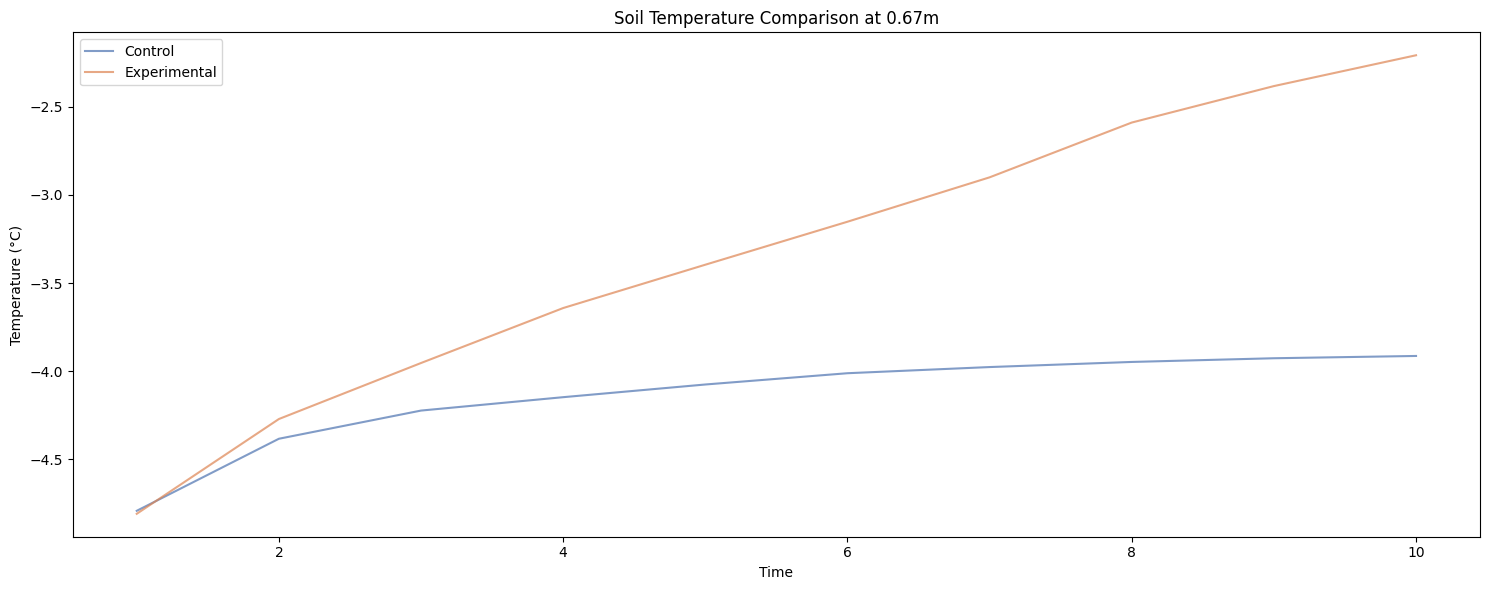

Statistics for 0.67m:
Control mean temperature: -4.14°C
Experimental mean temperature: -3.33°C
Temperature difference: 0.81°C
T-statistic: -2.8699
P-value: 0.0102




In [6]:
def plot_comparison(depth):
    plt.figure(figsize=(15, 6))
    plt.plot(control_df.index, control_df[depth], label='Control', alpha=0.7)
    plt.plot(experimental_df.index, experimental_df[depth], label='Experimental', alpha=0.7)
    plt.title(f'Soil Temperature Comparison at {depth}')
    plt.xlabel('Time')
    plt.ylabel('Temperature (°C)')
    plt.legend()
    plt.tight_layout()
    plt.show()
    # plt.savefig(f'comparison_{depth}.png')
    # plt.close()

    # Calculate and print statistics
    control_mean = control_df[depth].mean()
    exp_mean = experimental_df[depth].mean()
    temp_diff = exp_mean - control_mean
    t_stat, p_value = stats.ttest_ind(control_df[depth], experimental_df[depth])
    
    print(f"Statistics for {depth}:")
    print(f"Control mean temperature: {control_mean:.2f}°C")
    print(f"Experimental mean temperature: {exp_mean:.2f}°C")
    print(f"Temperature difference: {temp_diff:.2f}°C")
    print(f"T-statistic: {t_stat:.4f}")
    print(f"P-value: {p_value:.4f}")
    print("\n")

# Plot comparisons for each depth
for depth in depths:
    plot_comparison(depth)

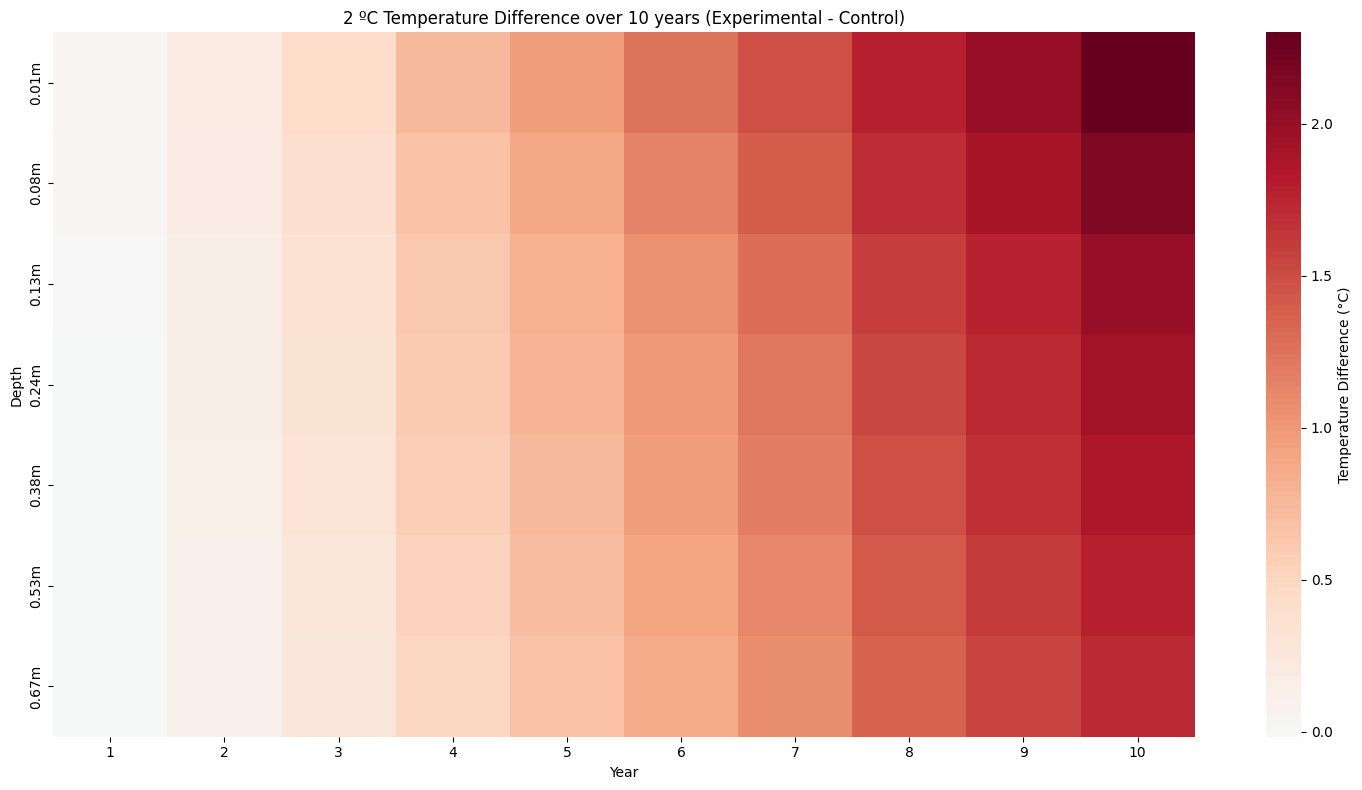

In [7]:
# Function to plot temperature difference heatmap
def plot_heatmap():
    # Calculate temperature differences
    diff_data = experimental_df[depths].values - control_df[depths].values

    # Create a heatmap of temperature differences
    plt.figure(figsize=(15, 8))
    sns.heatmap(diff_data.T, cmap='RdBu_r', center=0, cbar_kws={'label': 'Temperature Difference (°C)'}, 
                yticklabels=depths, xticklabels=control_df.index)
    plt.title('2 ºC Temperature Difference over 10 years (Experimental - Control)')
    plt.xlabel('Year')
    plt.ylabel('Depth')
    plt.tight_layout()
    plt.show()
    # Optionally save the heatmap
    # plt.savefig('temperature_difference_heatmap.png')
    # plt.close()

# Call the heatmap plotting function
plot_heatmap()

In [8]:
# Script for analyzing # of thawing degree days and # of freezing degree days
def calculate_thawing_freezing_days(data, depth):
    # Add a year column based on the index
    data['year'] = ((data.index - data.index[0]) // 365 + 1).astype(int)  # Create year based on days

    thawing_days = []
    freezing_days = []

    # Iterate through each year in the data
    for year in range(data['year'].min(), data['year'].max() + 1):
        year_data = data[data['year'] == year][depth]  # Filter data for the specific year
        thawing = (year_data > 0).sum()  # Count days where temperature > 0
        freezing = (year_data < 0).sum()  # Count days where temperature < 0
        thawing_days.append(thawing)
        freezing_days.append(freezing)

    return thawing_days, freezing_days

In [9]:
# Load control and experimental data
control_data_daily = np.loadtxt(CONTROL_PATH/'result.txt', skiprows=0, unpack=False)
experimental_data_daily = np.loadtxt(WD_PATH/'out/result.txt', skiprows=0,  unpack=False)

# Convert to pd data frame
control_df_daily = pd.DataFrame(control_data_daily, columns=['id', 'time', 'Tair', 'snow', '0.01m', '0.08m', '0.13m', '0.24m', '0.38m', '0.53m', '0.67m'])
experimental_df_daily = pd.DataFrame(experimental_data_daily, columns = ['id', 'time', 'Tair', 'snow', '0.01m', '0.08m', '0.13m', '0.24m', '0.38m', '0.53m', '0.67m'])

# Select needed columns
# Select 2nd column (index 1) and columns 5-11 (indices 4-10)
control_df_daily = control_df_daily.iloc[:, [1] + list(range(4, 11))]
experimental_df_daily = experimental_df_daily.iloc[:, [1] + list(range(4, 11))]
print(control_df_daily.head())

# # Set 'year' as the index
control_df_daily.set_index('time', inplace=True)
experimental_df_daily.set_index('time', inplace=True)

   time     0.01m     0.08m     0.13m     0.24m     0.38m     0.53m     0.67m
0   1.0 -9.252666 -8.285000 -7.752000 -7.429000 -6.909000 -6.581000 -6.293000
1   2.0 -8.527715 -8.043407 -7.703405 -7.468260 -7.053283 -6.807103 -6.623608
2   3.0 -8.387612 -7.954930 -7.665329 -7.471799 -7.135360 -6.927766 -6.760367
3   4.0 -8.220553 -7.879320 -7.639852 -7.476766 -7.187491 -7.003717 -6.849771
4   5.0 -8.028191 -7.767278 -7.584016 -7.454775 -7.213367 -7.052298 -6.912105


In [10]:
# Calculate thawing and freezing days for control and experimental data
for depth in depths:
    print(f"Thawing and freezing days for depth {depth}:")

    control_thawing, control_freezing = calculate_thawing_freezing_days(control_df_daily, depth)
    exp_thawing, exp_freezing = calculate_thawing_freezing_days(experimental_df_daily, depth)

    print("Control:")
    for year, (thawing, freezing) in enumerate(zip(control_thawing, control_freezing), start=control_df_daily['year'].min()):
        print(f"Year {year}: Thawing {thawing:.2f} days, Freezing {freezing:.2f} days")

    print("\nExperimental:")
    for year, (thawing, freezing) in enumerate(zip(exp_thawing, exp_freezing), start=experimental_df_daily['year'].min()):
        print(f"Year {year}: Thawing {thawing:.2f} days, Freezing {freezing:.2f} days")

    print("\n")

print("Analysis complete.")

Thawing and freezing days for depth 0.01m:
Control:
Year 1: Thawing 125.00 days, Freezing 240.00 days
Year 2: Thawing 126.00 days, Freezing 239.00 days
Year 3: Thawing 125.00 days, Freezing 240.00 days
Year 4: Thawing 125.00 days, Freezing 240.00 days
Year 5: Thawing 125.00 days, Freezing 240.00 days
Year 6: Thawing 125.00 days, Freezing 240.00 days
Year 7: Thawing 125.00 days, Freezing 240.00 days
Year 8: Thawing 125.00 days, Freezing 240.00 days
Year 9: Thawing 125.00 days, Freezing 240.00 days
Year 10: Thawing 125.00 days, Freezing 240.00 days

Experimental:
Year 1: Thawing 127.00 days, Freezing 238.00 days
Year 2: Thawing 127.00 days, Freezing 238.00 days
Year 3: Thawing 129.00 days, Freezing 236.00 days
Year 4: Thawing 131.00 days, Freezing 234.00 days
Year 5: Thawing 133.00 days, Freezing 232.00 days
Year 6: Thawing 137.00 days, Freezing 228.00 days
Year 7: Thawing 138.00 days, Freezing 227.00 days
Year 8: Thawing 138.00 days, Freezing 227.00 days
Year 9: Thawing 141.00 days, Fre